In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar tulisan tangan

In [2]:
img_bgr = cv2.imread('NAMA_RGB.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Memisahkan matriks gambar menjadi kanal Merah (R), Hijau (G), dan Biru (B)

In [3]:
R, G, B = cv2.split(img_rgb)

# Menyiapkan plot (bingkai) untuk menampilkan 4 gambar

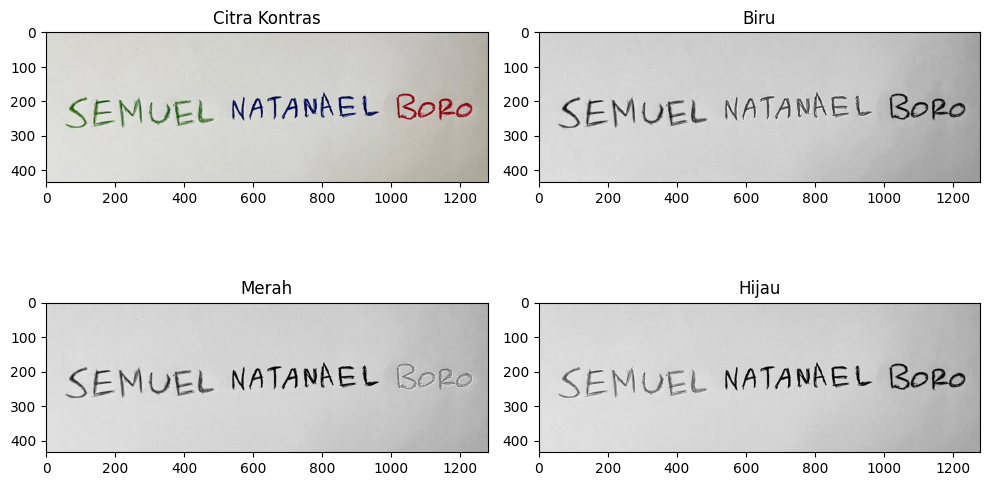

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Citra Kontras")
axes[0, 1].imshow(B, cmap='gray')
axes[0, 1].set_title("Biru")
axes[1, 0].imshow(R, cmap='gray')
axes[1, 0].set_title("Merah")
axes[1, 1].imshow(G, cmap='gray')
axes[1, 1].set_title("Hijau")

plt.tight_layout()
plt.show()

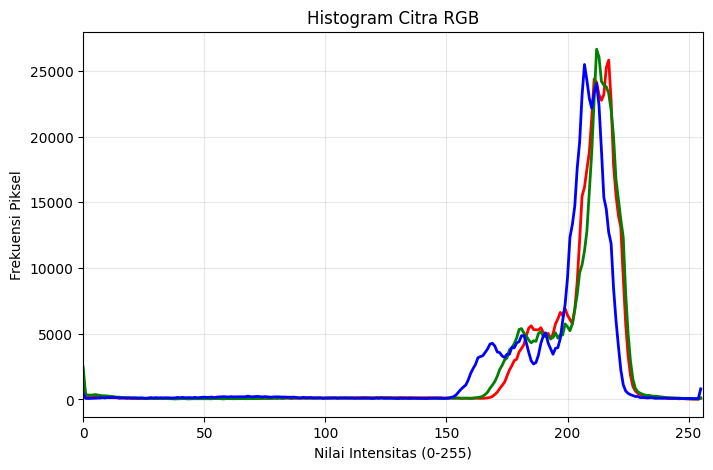

In [10]:
plt.figure(figsize=(8, 5))
warna = ('r', 'g', 'b')

# Looping untuk menghitung dan menggambar garis histogram tiap warna
for i, col in enumerate(warna):
    histr = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
    plt.plot(histr, color=col, linewidth=2)
    plt.xlim([0, 256])

plt.title('Histogram Citra RGB')
plt.xlabel('Nilai Intensitas (0-255)')
plt.ylabel('Frekuensi Piksel')
plt.grid(alpha=0.3)
plt.show()

# Menentukan nilai ambang batas

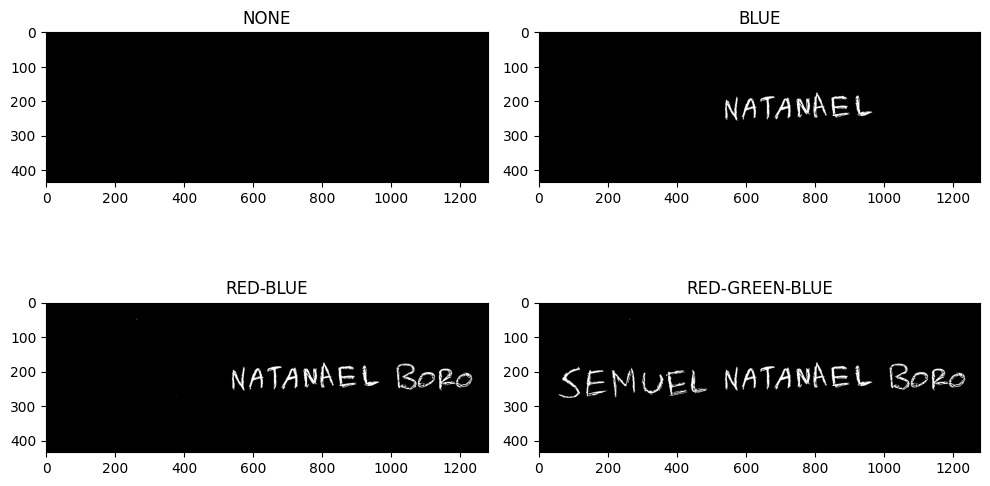

In [11]:
# Tinta menyerap cahaya, jadi nilainya lebih gelap dari kertas putih (< 150)
mask_biru = (B > R) & (B > G) & (B < 150)
mask_merah = (R > G) & (R > B) & (R < 150)
mask_hijau = (G > R) & (G > B) & (G < 150)

# Membuat background hitam kosong
img_none = np.zeros_like(img_rgb[:,:,0])

# Menerapkan mask: jika sesuai mask maka putih (255), sisanya hitam (0)
img_blue = np.where(mask_biru, 255, 0).astype(np.uint8)
img_red_blue = np.where(mask_biru | mask_merah, 255, 0).astype(np.uint8)
img_all = np.where(mask_biru | mask_merah | mask_hijau, 255, 0).astype(np.uint8)

# Menampilkan hasil
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 6))
axes2[0, 0].imshow(img_none, cmap='gray')
axes2[0, 0].set_title("NONE")
axes2[0, 1].imshow(img_blue, cmap='gray')
axes2[0, 1].set_title("BLUE")
axes2[1, 0].imshow(img_red_blue, cmap='gray')
axes2[1, 0].set_title("RED-BLUE")
axes2[1, 1].imshow(img_all, cmap='gray')
axes2[1, 1].set_title("RED-GREEN-BLUE")

plt.tight_layout()
plt.show()

# Membaca gambar backlight dan konversi ke RGB

In [8]:
import cv2 

img_backlight = cv2.imread('FOTO_BACKLIGHT.jpeg')
img_backlight = cv2.cvtColor(img_backlight, cv2.COLOR_BGR2RGB)

# Konversi ke Grayscale

In [9]:
img_gray = cv2.cvtColor(img_backlight, cv2.COLOR_RGB2GRAY)

beta = 60       
alpha = 1.3

# Proses Manipulasi Piksel

In [10]:
img_cerah = cv2.convertScaleAbs(img_gray, alpha=1.0, beta=beta)
img_kontras = cv2.convertScaleAbs(img_gray, alpha=alpha, beta=0)
img_final = cv2.convertScaleAbs(img_gray, alpha=alpha, beta=beta)

# Menampilkan 5 output 

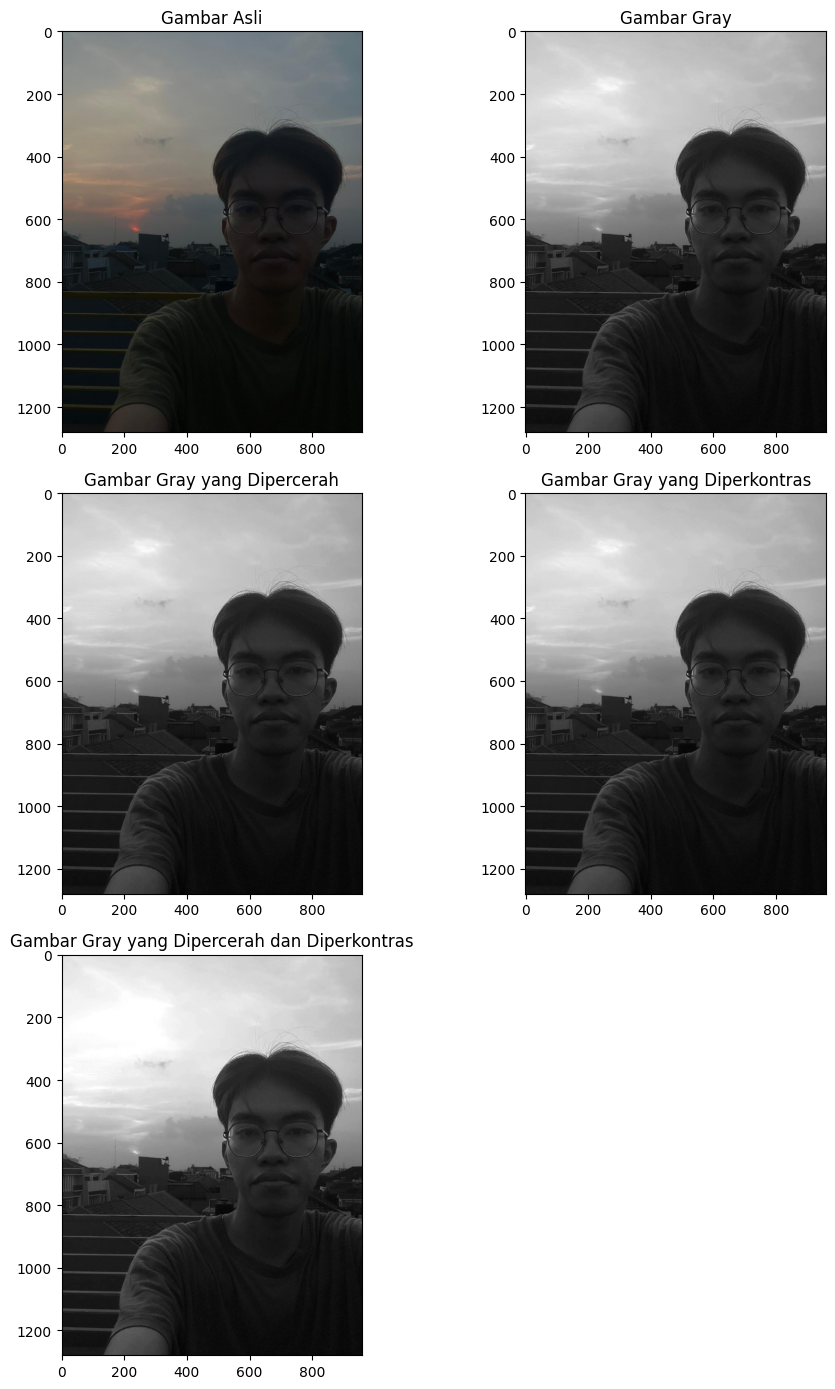

In [11]:
fig3, axes3 = plt.subplots(3, 2, figsize=(10, 14))

axes3[0, 0].imshow(img_backlight)
axes3[0, 0].set_title("Gambar Asli")
axes3[0, 1].imshow(img_gray, cmap='gray')
axes3[0, 1].set_title("Gambar Gray")
axes3[1, 0].imshow(img_cerah, cmap='gray')
axes3[1, 0].set_title("Gambar Gray yang Dipercerah")
axes3[1, 1].imshow(img_kontras, cmap='gray')
axes3[1, 1].set_title("Gambar Gray yang Diperkontras")
axes3[2, 0].imshow(img_final, cmap='gray')
axes3[2, 0].set_title("Gambar Gray yang Dipercerah dan Diperkontras")

fig3.delaxes(axes3[2,1])
plt.tight_layout()
plt.show()